In [128]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.stats import multivariate_normal
import metricas_plots

In [129]:
importlib.reload(metricas_plots)
from metricas_plots import PlotsMetricas, T, F
p = PlotsMetricas()

### Ler dados

In [130]:
dados = pd.read_csv("dados/ariel_limpo_log10.csv.gz", compression="gzip")

In [131]:
# Definir feature, target e gerar splits
col_x = F.atflux.value
larguras = p.targets[:4]
train, test = train_test_split(dados[[col_x] + larguras], test_size=0.3, random_state=4321)

## Calcular Estatísticas por Bin para o treinamento

In [132]:
# Faz o agrupamento dos dados
nbins = 150
train[f'{col_x}_mean'] = pd.qcut(train[col_x], nbins)
test[f'{col_x}_mean'] = pd.qcut(test[col_x], nbins)

# Covariâncias (matriz triângular, 6 valores)
cov_pairs = [
    (larguras[0], larguras[1]),
    (larguras[0], larguras[2]),
    (larguras[0], larguras[3]),
    (larguras[1], larguras[2]),
    (larguras[1], larguras[3]),
    (larguras[2], larguras[3])
]

def gera_stats(dados_split):
    stats_list = []
    for bin_name, group in dados_split.groupby(f'{col_x}_mean'):
        if len(group) < 5:  # Pular bins com poucos dados
            continue
        
        # Ponto central de cada bin
        col_center = group[col_x].mean()
        
        # Calcular média e desvio padrão
        dados_larguras = group[larguras].values
        means = dados_larguras.mean(axis=0)
        stds = dados_larguras.std(axis=0)
        
        # Calcular matriz de covariância 4x4
        cov_matrix = np.cov(dados_larguras, rowvar=False)
        
        # Montar dicionário com todas as estatísticas
        stat_dict = {col_x: col_center}    
        for i, largura in enumerate(larguras):
            stat_dict[f'{largura}_mean'] = means[i]
            stat_dict[f'{largura}_std'] = stds[i]
        for l1, l2 in cov_pairs:
            i1 = larguras.index(l1)
            i2 = larguras.index(l2)
            stat_dict[f'cov_{l1}_{l2}'] = cov_matrix[i1, i2]
        
        stats_list.append(stat_dict)
    return stats_list

train_por_bin = pd.DataFrame(gera_stats(train))
test_por_bin = pd.DataFrame(gera_stats(test))
test_por_bin.tail()

,atflux,nii_6584_ew_mean,nii_6584_ew_std,halpha_ew_mean,halpha_ew_std,oiii_5007_ew_mean,oiii_5007_ew_std,hbeta_ew_mean,hbeta_ew_std,cov_nii_6584_ew_halpha_ew,cov_nii_6584_ew_oiii_5007_ew,cov_nii_6584_ew_hbeta_ew,cov_halpha_ew_oiii_5007_ew,cov_halpha_ew_hbeta_ew,cov_oiii_5007_ew_hbeta_ew
145,9.936057,0.168240,0.337353,0.184126,0.350832,-0.132068,0.352442,-0.343990,0.316478,0.098732,0.078205,0.066696,0.076102,0.090128,0.062899
146,9.953530,0.146480,0.366839,0.154429,0.366735,-0.064135,0.375703,-0.330346,0.305108,0.117319,0.098872,0.077623,0.096829,0.090753,0.076060
147,9.976064,0.090506,0.360489,0.104975,0.343373,-0.152011,0.349344,-0.349738,0.294379,0.105574,0.087449,0.062964,0.082221,0.078180,0.054651
148,10.002888,0.121326,0.329624,0.105295,0.338760,-0.150484,0.313223,-0.364700,0.280543,0.092870,0.064966,0.052312,0.069248,0.072940,0.047429
149,10.034016,0.142487,0.335264,0.173500,0.338625,-0.107809,0.301950,-0.326246,0.292027,0.093773,0.058384,0.058496,0.063084,0.078273,0.047533


## Treinar Operons para Média, Desvio Padrão e Covariâncias

In [133]:
# Dicionário para armazenar os modelos
modelos = {}

# 1. Treinar modelos para MÉDIA (4 modelos)
def treinar_medias(hyper, X_train_bins):
    print("\n[1/3] TREINANDO MODELOS DE MÉDIA")
    print("-" * 80)
    for largura in larguras:
        print(f"Treinando MÉDIA para {largura}...")
        y = train_por_bin[f'{largura}_mean'].values.astype(np.float64)
        modelo = p.treinar_operon(hyper, X_train_bins, y)
        modelos[f'{largura}_mean'] = modelo

# 2. Treinar modelos para DESVIO PADRÃO (4 modelos)
def treinar_stds(hyper, X_train_bins):
    print("\n[2/3] TREINANDO MODELOS DE DESVIO PADRÃO")
    print("-" * 80)
    for largura in larguras:
        print(f"Treinando DESVIO PADRÃO para {largura}...")
        y = train_por_bin[f'{largura}_std'].values.astype(np.float64)
        modelo = p.treinar_operon(hyper, X_train_bins, y)
        modelos[f'{largura}_std'] = modelo

# 3. Treinar modelos para COVARIÂNCIAS (6 modelos)
def treinar_covs(hyper, X_train_bins):
    print("\n[3/3] TREINANDO MODELOS DE COVARIÂNCIA")
    print("-" * 80)
    for l1, l2 in cov_pairs:
        print(f"Treinando COVARIÂNCIA para {l1} x {l2}...")
        y = train_por_bin[f'cov_{l1}_{l2}'].values.astype(np.float64)
        modelo = p.treinar_operon(hyper, X_train_bins, y)
        modelos[f'cov_{l1}_{l2}'] = modelo

In [134]:
# Selecionar feature para o treinamento
X_train_bins = train_por_bin[col_x].values.reshape(-1, 1).astype(np.float64)

# Configuração do Operon
hyper = {
    'allowed_symbols': "add,sub,mul,aq,constant,variable,square,pow,abs,sqrt,exp,log,tanh",
    'random_state': 4321,
    'population_size': 2000,
    'generations': 1000,
    'optimizer_iterations': 500,
    'max_depth': 20,
    'n_threads': 12,
    'model_selection_criterion': 'bayesian_information_criterion',
    'objectives': ['r2', 'length']
}

treinar_medias(hyper, X_train_bins)
treinar_stds(hyper, X_train_bins)
treinar_covs(hyper, X_train_bins)
p.salva_equacoes_html(modelos, col_x, f"{col_x}_n4d")


[1/3] TREINANDO MODELOS DE MÉDIA
--------------------------------------------------------------------------------
Treinando MÉDIA para nii_6584_ew...
Treinando MÉDIA para halpha_ew...
Treinando MÉDIA para oiii_5007_ew...
Treinando MÉDIA para hbeta_ew...

[2/3] TREINANDO MODELOS DE DESVIO PADRÃO
--------------------------------------------------------------------------------
Treinando DESVIO PADRÃO para nii_6584_ew...
Treinando DESVIO PADRÃO para halpha_ew...
Treinando DESVIO PADRÃO para oiii_5007_ew...
Treinando DESVIO PADRÃO para hbeta_ew...

[3/3] TREINANDO MODELOS DE COVARIÂNCIA
--------------------------------------------------------------------------------
Treinando COVARIÂNCIA para nii_6584_ew x halpha_ew...
Treinando COVARIÂNCIA para nii_6584_ew x oiii_5007_ew...
Treinando COVARIÂNCIA para nii_6584_ew x hbeta_ew...
Treinando COVARIÂNCIA para halpha_ew x oiii_5007_ew...
Treinando COVARIÂNCIA para halpha_ew x hbeta_ew...
Treinando COVARIÂNCIA para oiii_5007_ew x hbeta_ew...

----

## Inspeção da qualidade dos modelos

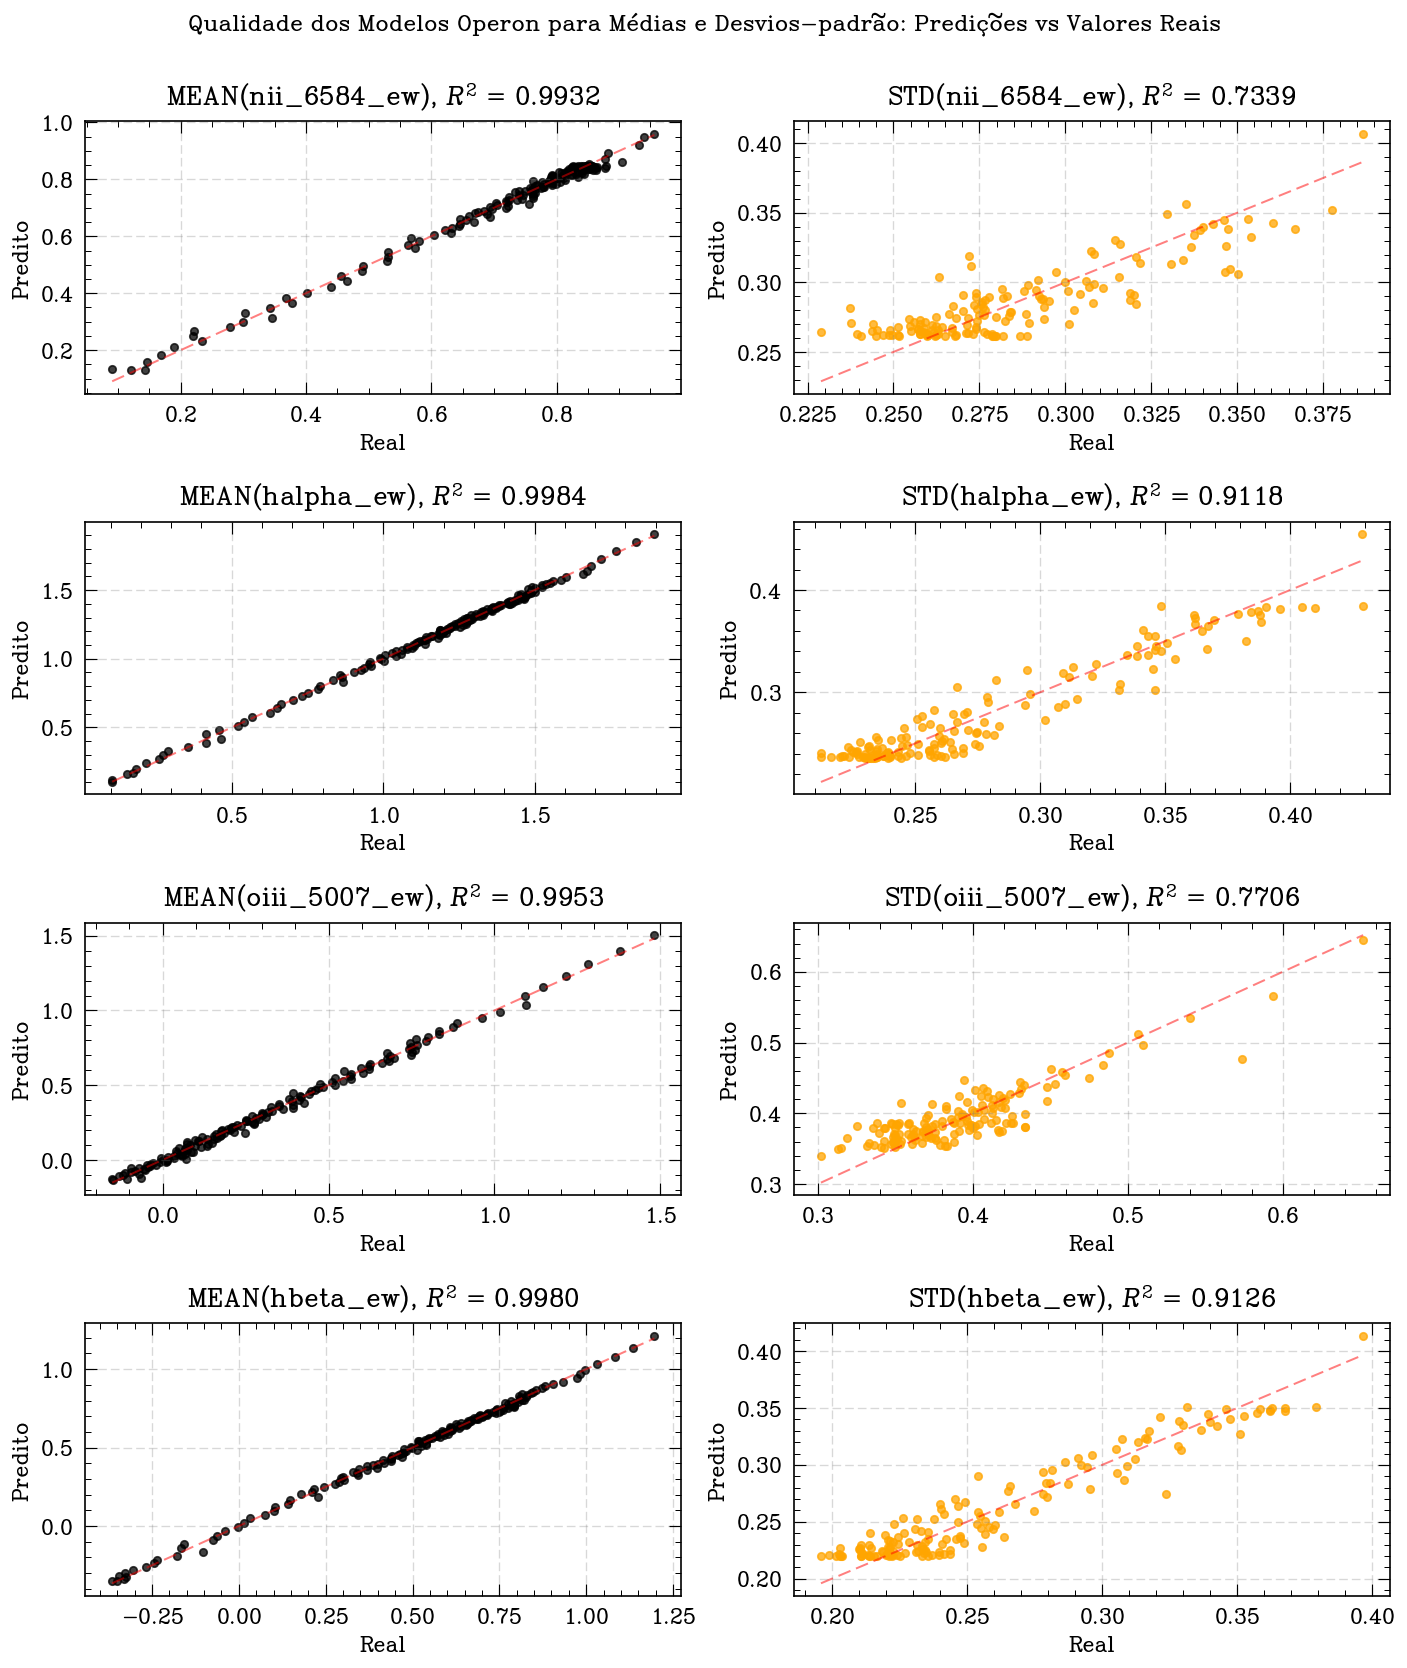

In [135]:
# Valores do conjunto de validação
X_test_bins = test_por_bin[col_x].values.reshape(-1, 1)

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
fig.suptitle('Qualidade dos Modelos Operon para Médias e Desvios-padrão: Predições vs Valores Reais', fontsize=16, y=0.995)

# Médias
for idx, linha in enumerate(larguras):
    ax_mean = axes[idx, 0]
    y_true_mean = test_por_bin[f'{linha}_mean'].values
    y_pred_mean = modelos[f'{linha}_mean'].predict(X_test_bins)
    r2_mean = modelos[f'{linha}_mean'].score(X_test_bins, y_true_mean)
    ax_mean.plot([y_true_mean.min(), y_true_mean.max()], 
                 [y_true_mean.min(), y_true_mean.max()], '--', color='red', alpha=0.5)
    ax_mean.scatter(y_true_mean, y_pred_mean, alpha=0.75, s=20)
    ax_mean.set_xlabel('Real')
    ax_mean.set_ylabel('Predito')
    ax_mean.set_title(f'MEAN({linha}), $R^2$ = {r2_mean:.4f}')
    ax_mean.grid(True, alpha=0.3)

# Desvios-padrão
for idx, linha in enumerate(larguras):
    ax_std = axes[idx, 1]
    y_true_std = test_por_bin[f'{linha}_std'].values
    y_pred_std = modelos[f'{linha}_std'].predict(X_test_bins)
    r2_std = modelos[f'{linha}_std'].score(X_test_bins, y_true_std)
    ax_std.plot([y_true_std.min(), y_true_std.max()], 
                [y_true_std.min(), y_true_std.max()], '--', color='red', alpha=0.5)
    ax_std.scatter(y_true_std, y_pred_std, alpha=0.75, s=20, color='orange')
    ax_std.set_xlabel('Real')
    ax_std.set_ylabel('Predito')
    ax_std.set_title(f'STD({linha}), $R^2$ = {r2_std:.4f}')
    ax_std.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

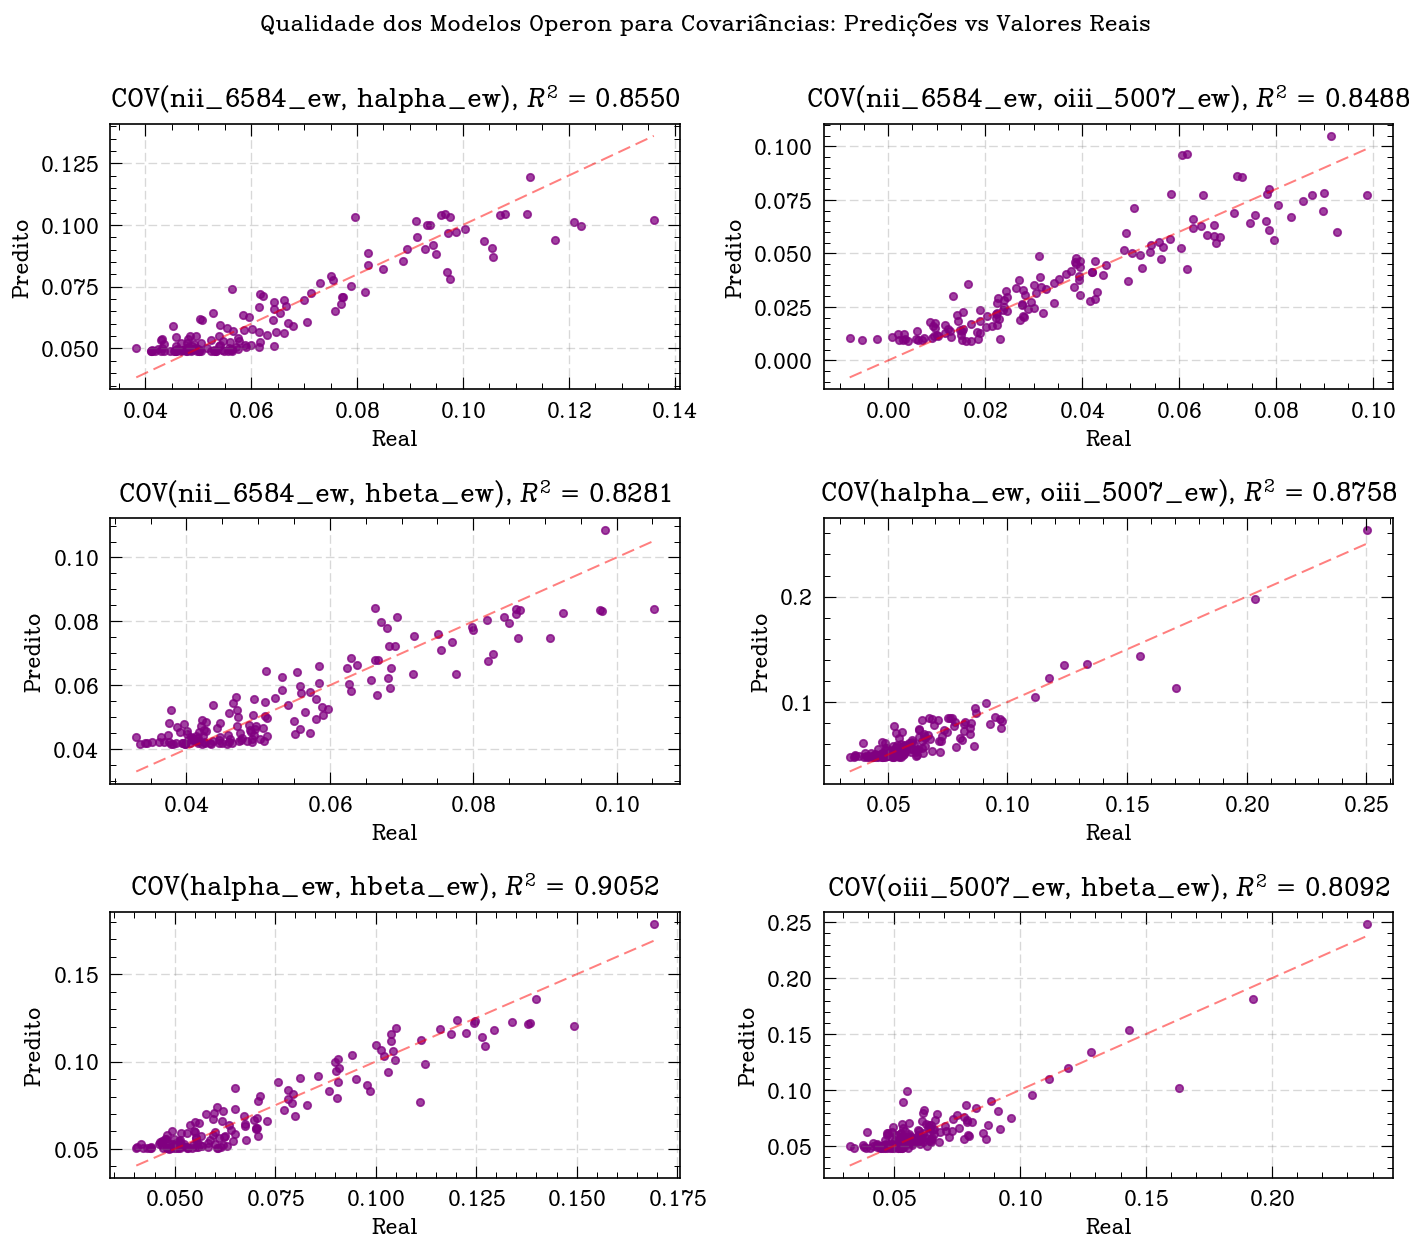

In [136]:
# Inspeção da qualidade dos modelos de covariância
fig, axes = plt.subplots(3, 2, figsize=(12, 10.5))
fig.suptitle('Qualidade dos Modelos Operon para Covariâncias: Predições vs Valores Reais', fontsize=16, y=0.995)

for idx, (l1, l2) in enumerate(cov_pairs):
    ax = axes[idx // 2, idx % 2]
    
    #  Covariâncias
    y_true_cov = test_por_bin[f'cov_{l1}_{l2}'].values
    y_pred_cov = modelos[f'cov_{l1}_{l2}'].predict(X_test_bins)
    r2_cov = modelos[f'cov_{l1}_{l2}'].score(X_test_bins, y_true_cov)
    
    ax.scatter(y_true_cov, y_pred_cov, alpha=0.75, s=20, color='purple')
    ax.plot([y_true_cov.min(), y_true_cov.max()], 
            [y_true_cov.min(), y_true_cov.max()], 'r--', alpha=0.5)
    ax.set_xlabel('Real')
    ax.set_ylabel('Predito')
    ax.set_title(f'COV({l1}, {l2}), $R^2$ = {r2_cov:.4f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Exibir alguma função treinada de interesse
x_pred = test[[col_x]]
y_pred = modelos[f'cov_{T.ha.value}_{T.oiii.value}'].predict(x_pred)
plt.scatter(x_pred, y_pred, s=1, alpha=0.5)
plt.show()

## Gerar Amostras do Conjunto de Teste com Normal Multivariada

In [138]:
X_test = test[[col_x]].astype(np.float64)
n_samples = len(X_test)

print(f"Estimando parâmetros de {n_samples} pontos do conjunto de validação para a Normal Multivariada...\n")

means_all = np.column_stack([modelos[f'{nome}_mean'].predict(X_test) for nome in larguras])
stds_all = np.column_stack([np.maximum(modelos[f'{nome}_std'].predict(X_test), 1e-6) for nome in larguras])
covs_all = {}
for l1, l2 in cov_pairs:
    covs_all[(l1, l2)] = modelos[f'cov_{l1}_{l2}'].predict(X_test)

print("Predições dos estimadores concluídas!")

n_correcoes = 0
amostras_multivariadas = np.zeros((n_samples, 4))
idx_map = {nome: j for j, nome in enumerate(larguras)}
print("\nAmostragem multivariada iniciada..\n")

for i in range(n_samples):
    if i % 5000 == 0 and i > 0:
        print(f"  Progresso: {i}/{n_samples} ({100*i/n_samples:.1f}%)")
    
    # Montar matriz de covariância
    mean_vector = means_all[i]
    stds = stds_all[i]    
    cov_matrix = np.diag(stds**2)
    for (l1_nome, l2_nome), cov_vals in covs_all.items():
        i1 = idx_map[l1_nome]
        i2 = idx_map[l2_nome]
        cov_matrix[i1, i2] = cov_vals[i]
        cov_matrix[i2, i1] = cov_vals[i]
    
    # Regularização robusta
    #cov_matrix = np.nan_to_num(cov_matrix, nan=0.0, posinf=0.0, neginf=0.0)
    corrigiu = False
    try:
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        if np.any(eigenvalues < 1e-8):
            eigenvalues = np.maximum(eigenvalues, 1e-8)
            cov_matrix = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
            corrigiu = True
        
        sample = multivariate_normal(mean=mean_vector, cov=cov_matrix, allow_singular=True).rvs()
    except:
        # Fallback: diagonal apenas
        cov_matrix = np.diag(stds**2)
        sample = multivariate_normal(mean=mean_vector, cov=cov_matrix, allow_singular=True).rvs()
        corrigiu = True
    finally:
        if corrigiu: n_correcoes += 1
    
    amostras_multivariadas[i] = sample

amostras = {
    col_x: X_test,
    larguras[0]: amostras_multivariadas[:, 0],
    larguras[1]: amostras_multivariadas[:, 1],
    larguras[2]: amostras_multivariadas[:, 2],
    larguras[3]: amostras_multivariadas[:, 3]
}

print("\nAmostragem multivariada concluída!")
print(f"   - Amostras: {n_samples}")
print(f"   - Matrizes corrigidas: {n_correcoes} ({100*n_correcoes/n_samples:.1f}%)\n")

print("Estatísticas:\n")
for nome in larguras:
    valores = amostras[nome]
    print(f"  {nome:12s}: média={valores.mean():7.3f}, std={valores.std():6.3f}, "
          f"min={valores.min():7.3f}, max={valores.max():7.3f}")

Estimando parâmetros de 37746 pontos do conjunto de validação para a Normal Multivariada...

Predições dos estimadores concluídas!

Amostragem multivariada iniciada..

  Progresso: 5000/37746 (13.2%)
  Progresso: 10000/37746 (26.5%)
  Progresso: 15000/37746 (39.7%)
  Progresso: 20000/37746 (53.0%)
  Progresso: 25000/37746 (66.2%)
  Progresso: 30000/37746 (79.5%)
  Progresso: 35000/37746 (92.7%)

Amostragem multivariada concluída!
   - Amostras: 37746
   - Matrizes corrigidas: 959 (2.5%)

Estatísticas:

  nii_6584_ew : média=  0.706, std= 0.343, min= -0.920, max=  2.483
  halpha_ew   : média=  1.153, std= 0.470, min= -0.999, max=  2.900
  oiii_5007_ew: média=  0.332, std= 0.528, min= -1.662, max=  3.048
  hbeta_ew    : média=  0.499, std= 0.430, min= -1.426, max=  2.298


## Calcular razões do BPT

VERIFICAÇÃO: Correlações preservadas nas amostras geradas

Diferença Absoluta - (Amostras - Teste):
              nii_6584_ew  halpha_ew  oiii_5007_ew  hbeta_ew
nii_6584_ew         0.000      0.007         0.007     0.004
halpha_ew           0.007      0.000         0.001     0.001
oiii_5007_ew        0.007      0.001         0.000     0.002
hbeta_ew            0.004      0.001         0.002     0.000

Diferença Absoluta Média: 0.0035


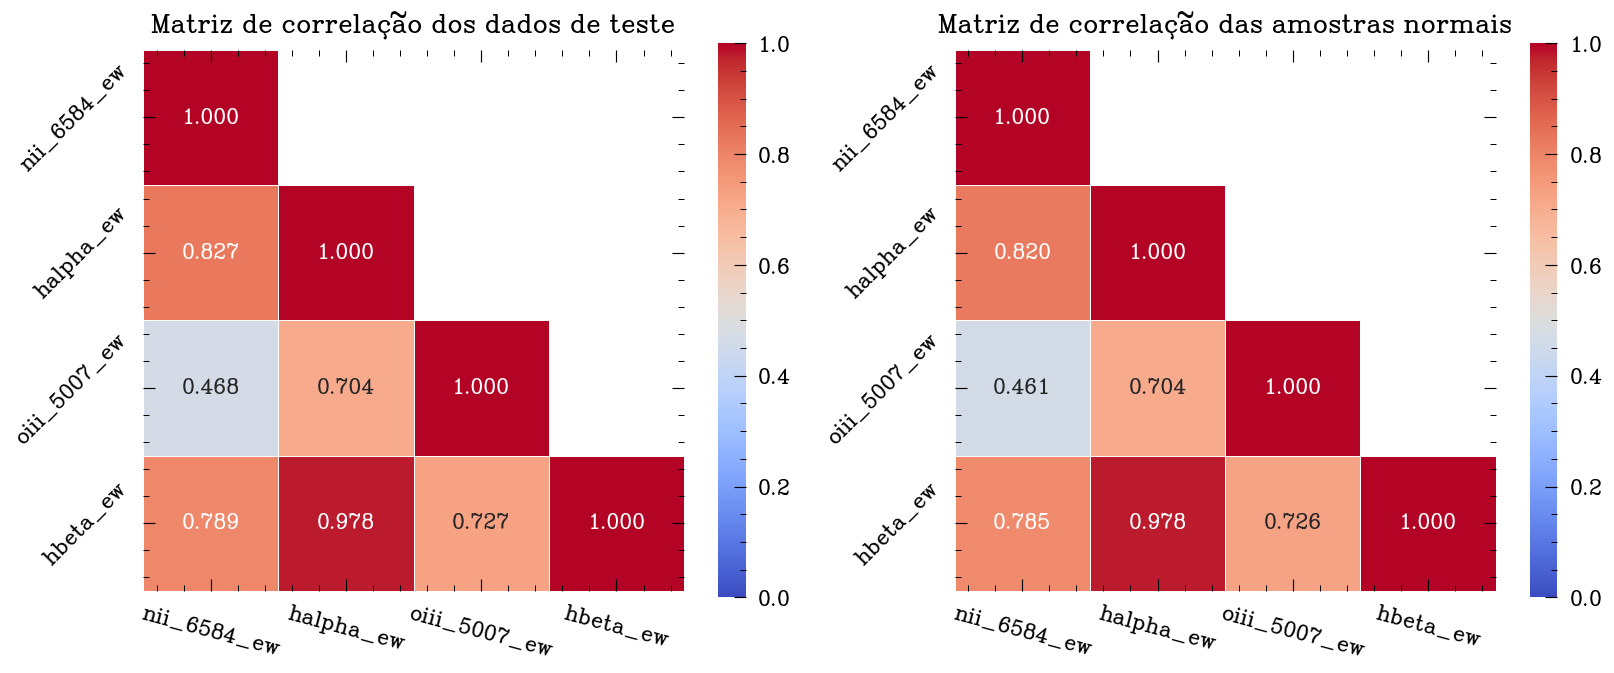

In [139]:
# Calcular razões (já estão em log10, então é só subtrair)
test[T.nii_ha.value] = test[T.nii.value].values - test[T.ha.value].values
test[T.oiii_hb.value] = test[T.oiii.value].values - test[T.hb.value].values
amostras[T.nii_ha.value] = amostras[T.nii.value] - amostras[T.ha.value]
amostras[T.oiii_hb.value] = amostras[T.oiii.value] - amostras[T.hb.value]

# Verificar se as correlações foram preservadas
print("VERIFICAÇÃO: Correlações preservadas nas amostras geradas")
print("="*80)

# Matriz de correlação das amostras geradas
amostras_array = np.column_stack([amostras[nome] for nome in larguras])
corr_gerada = np.corrcoef(amostras_array, rowvar=False)

# Matriz de correlação dos dados reais (test set)
test_linhas = test[larguras].values
corr_real = np.corrcoef(test_linhas, rowvar=False)

# Criar tabelas de comparação
df_test = pd.DataFrame(corr_real, index=larguras, columns=larguras)
df_amostras = pd.DataFrame(corr_gerada, index=larguras, columns=larguras)

print("\nDiferença Absoluta - (Amostras - Teste):")
diff_df = (df_amostras - df_test).abs()
print(diff_df.round(3))

print(f"\nDiferença Absoluta Média: {diff_df.values[np.triu_indices(4, k=1)].mean():.4f}")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
p.plot_corr(corr_real, axes[0], larguras, title='Matriz de correlação dos dados de teste', type='inf')
p.plot_corr(corr_gerada, axes[1], larguras, title='Matriz de correlação das amostras normais', type='inf')
plt.show()

### Diagramas de diagnóstico

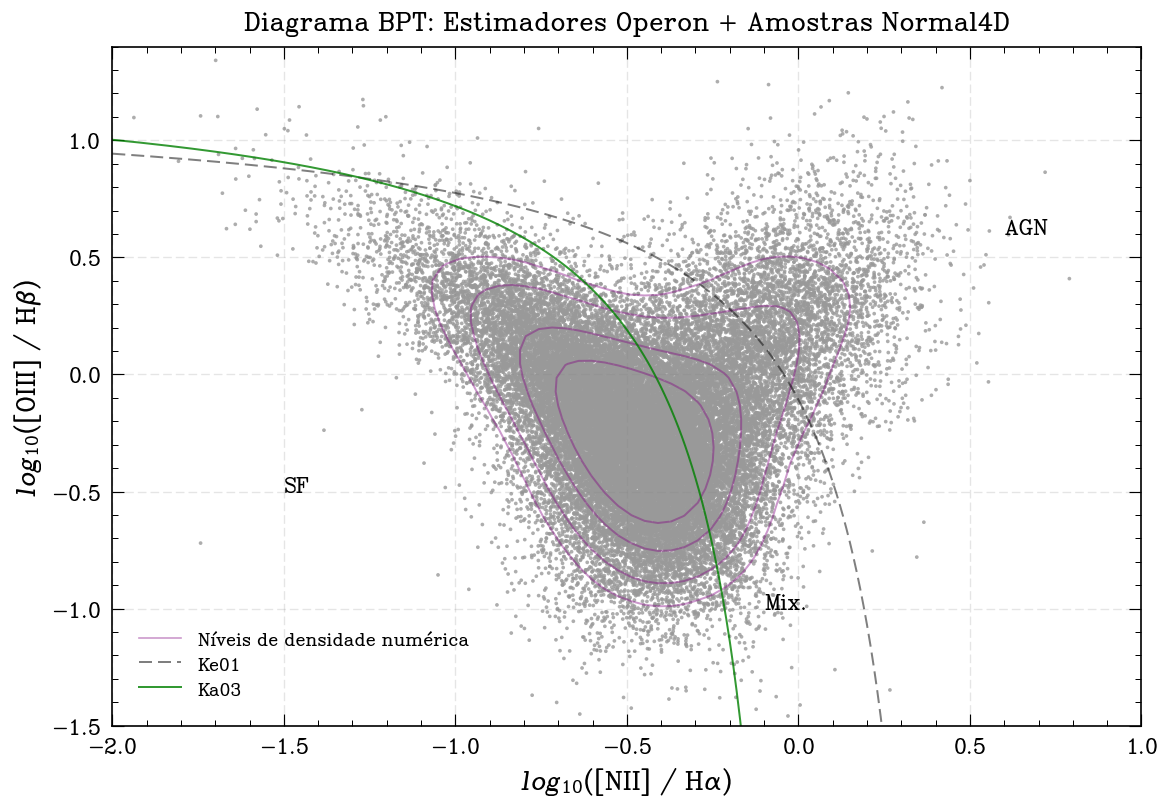

In [140]:
# Plotar com curvas de densidade
p.show_bpt(amostras, title="Estimadores Operon + Amostras Normal4D")

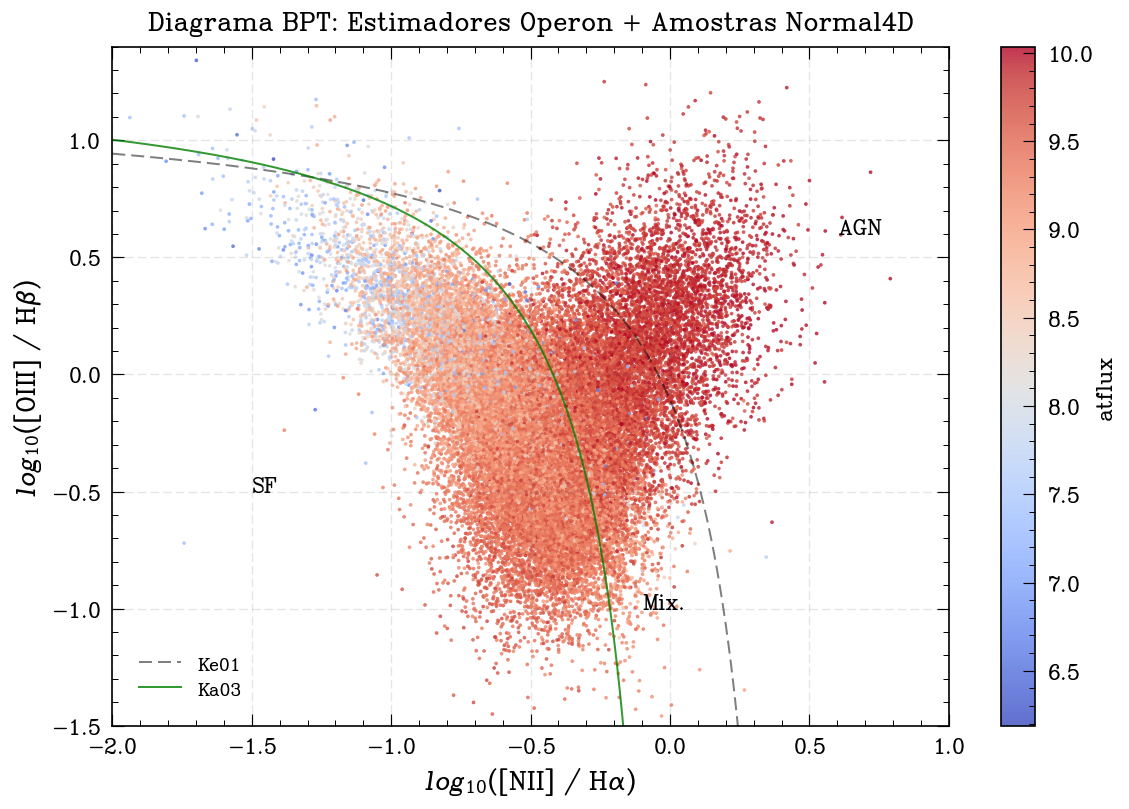

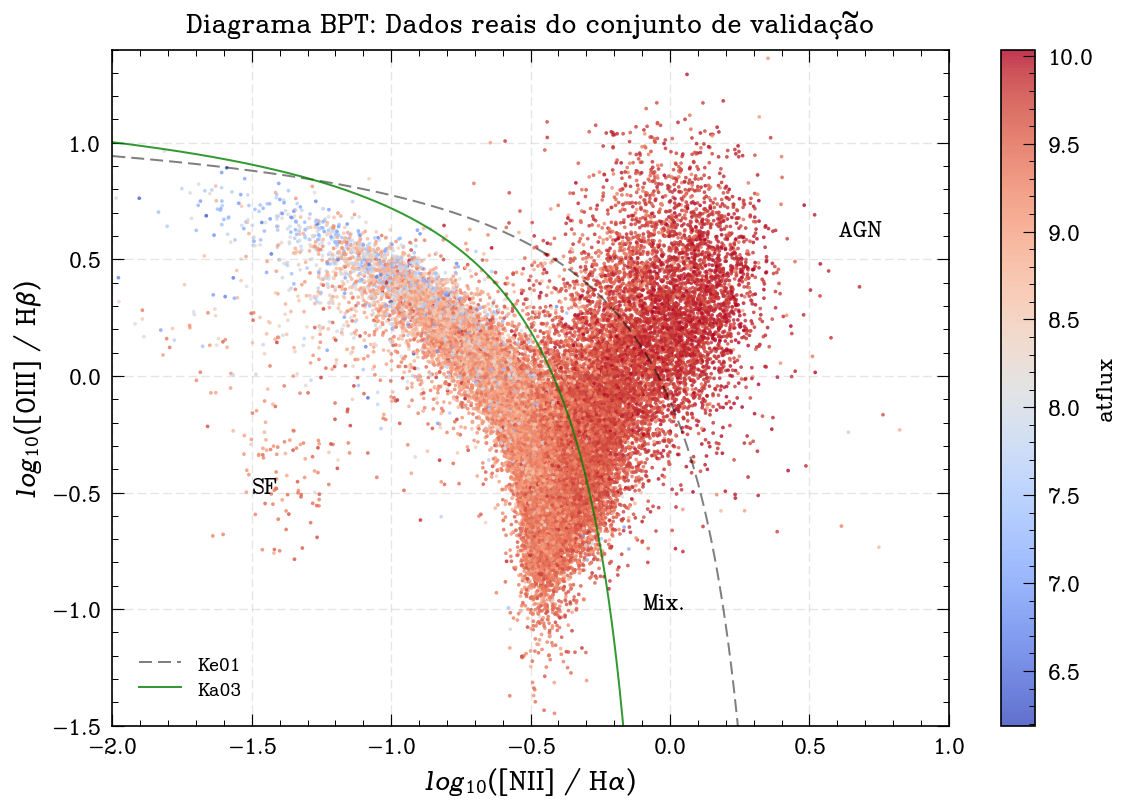

In [141]:
# Plotar amostras geradas coloridas por alguma feature
p.show_bpt(amostras, col_x, title="Estimadores Operon + Amostras Normal4D")
p.show_bpt(test, col_x, title="Dados reais do conjunto de validação")

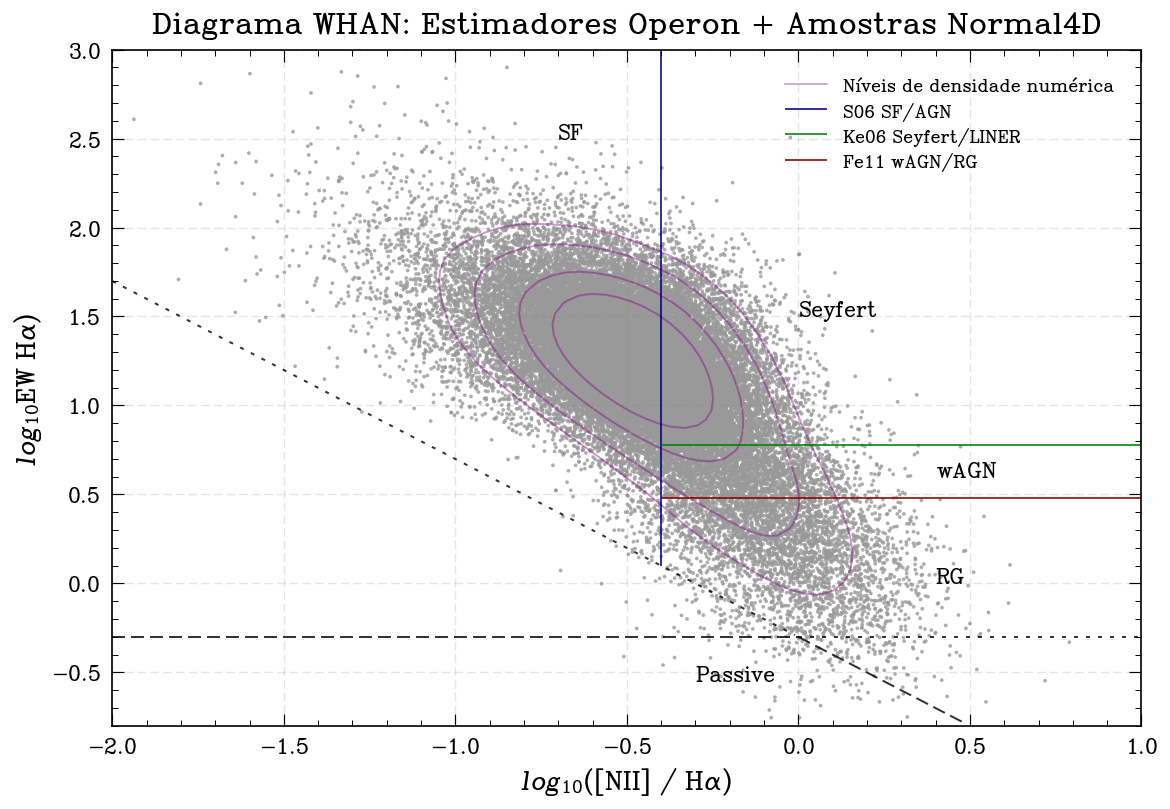

In [142]:
# Plotar com curvas de densidade
p.show_whan(amostras, title="Estimadores Operon + Amostras Normal4D")

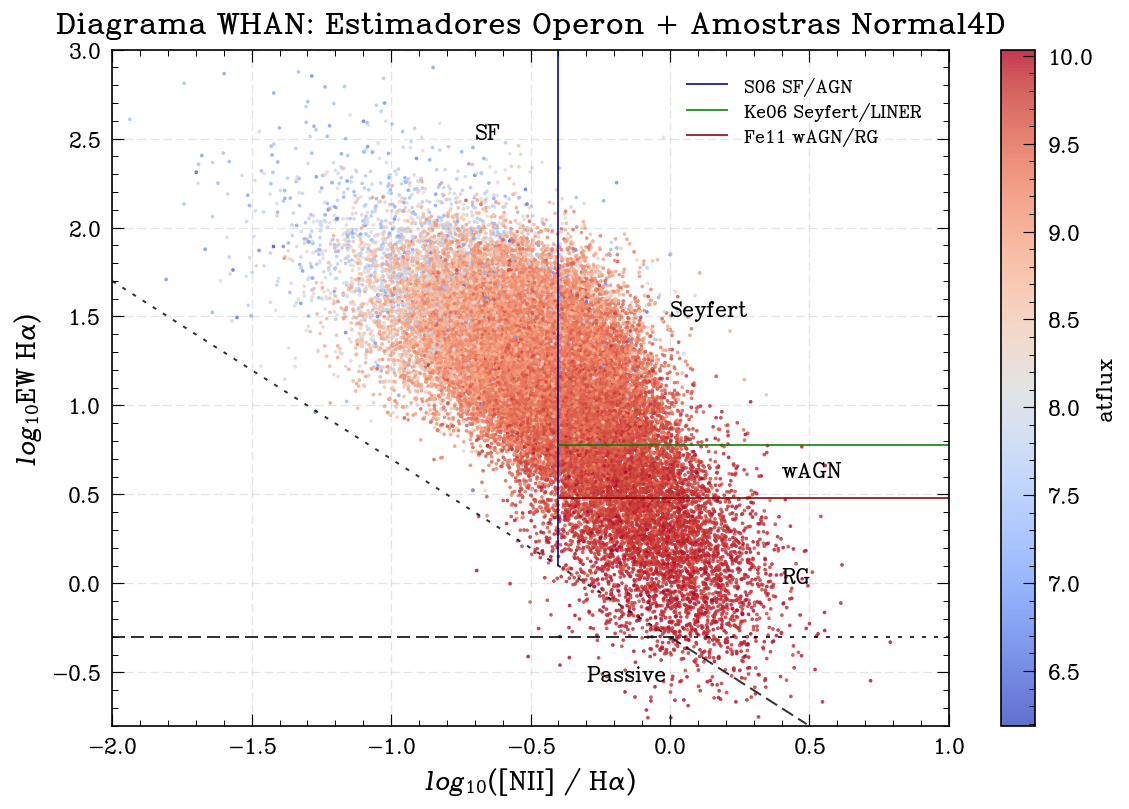

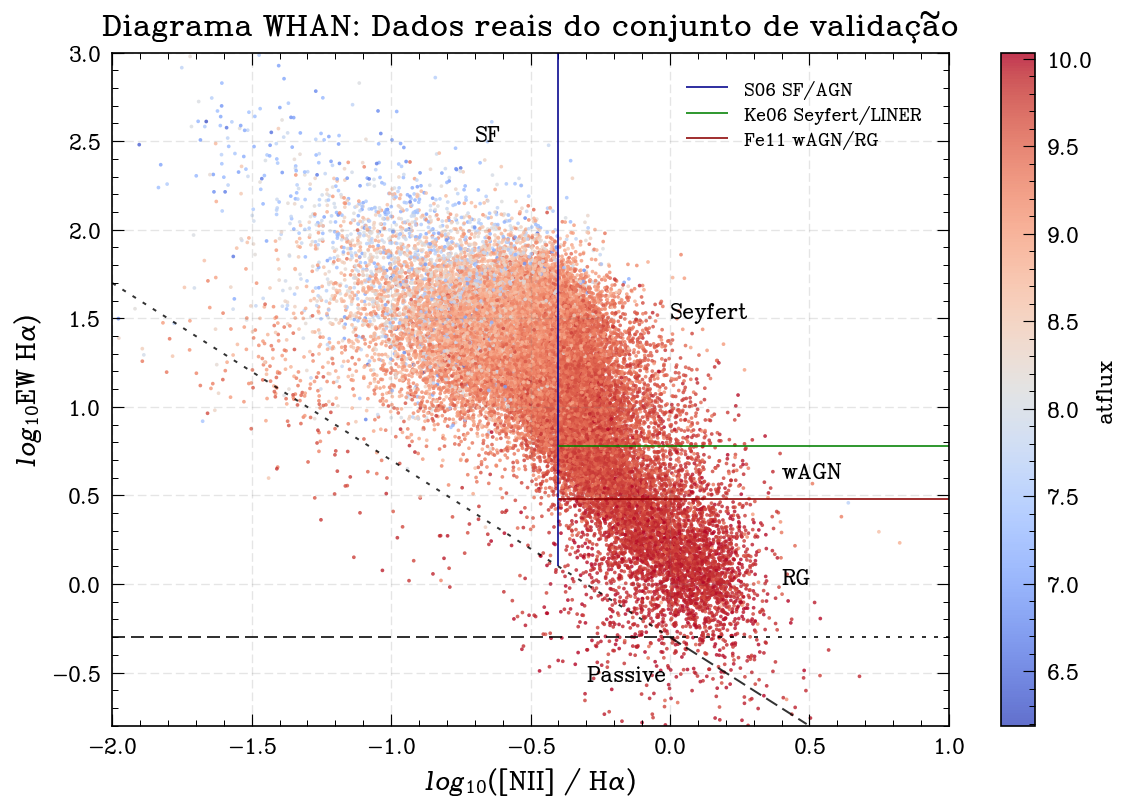

In [143]:
p.show_whan(amostras, col_x, title="Estimadores Operon + Amostras Normal4D")
p.show_whan(test, col_x, title="Dados reais do conjunto de validação")